=== 5 Data Teratas Training ===
     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                          tweet_text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

=== Distribusi Label di Data Training ===
sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

=== Distribusi Label di Data Validasi ===
sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64


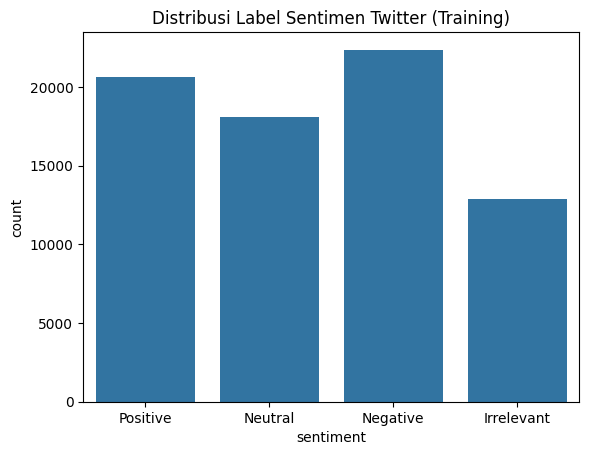

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan nama kolom karena dataset ini biasanya tidak memiliki header
nama_kolom = ['id', 'entity', 'sentiment', 'tweet_text']

# Memuat data training dan validation
df_train = pd.read_csv('../data/twitter_training.csv', names=nama_kolom, header=None)
df_val = pd.read_csv('../data/twitter_validation.csv', names=nama_kolom, header=None)

# Menghapus baris yang kosong (missing values) pada kolom teks jika ada
df_train = df_train.dropna(subset=['tweet_text'])
df_val = df_val.dropna(subset=['tweet_text'])

print("=== 5 Data Teratas Training ===")
print(df_train.head())

print("\n=== Distribusi Label di Data Training ===")
print(df_train['sentiment'].value_counts())

print("\n=== Distribusi Label di Data Validasi ===")
print(df_val['sentiment'].value_counts())

# Visualisasi distribusi label training
sns.countplot(x='sentiment', data=df_train)
plt.title('Distribusi Label Sentimen Twitter (Training)')
plt.show()

In [20]:
import re
import nltk
from nltk.corpus import stopwords

# Download library stopword dari NLTK (jalankan sekali saja)
nltk.download('stopwords')
stop_words_en = set(stopwords.words('english'))

def bersihkan_teks_twitter(text):
    if not isinstance(text, str):
        return ""

    # a. Case Folding
    text = text.lower()

    # b. Menghapus mention
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)

    # c. Menghapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # d. Menghapus hashtag (#)
    text = re.sub(r'#', '', text)

    # e. Menghapus angka dan tanda baca
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # f. Tokenisasi
    tokens = text.split()

    # g. Stopword removal
    tokens_bersih = [kata for kata in tokens if kata not in stop_words_en]

    return " ".join(tokens_bersih)

print("Sedang memproses pra-pemrosesan teks data training...")
df_train['teks_bersih'] = df_train['tweet_text'].apply(bersihkan_teks_twitter)

print("Sedang memproses pra-pemrosesan teks data validasi...")
df_val['teks_bersih'] = df_val['tweet_text'].apply(bersihkan_teks_twitter)

print("Pra-pemrosesan selesai!")

Sedang memproses pra-pemrosesan teks data training...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sedang memproses pra-pemrosesan teks data validasi...
Pra-pemrosesan selesai!


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Menentukan Fitur (X) dan Target (y)
X_train = df_train['teks_bersih']
y_train = df_train['sentiment']

X_test = df_val['teks_bersih']
y_test = df_val['sentiment']

# Ekstraksi Fitur menggunakan TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Dimensi data training setelah TF-IDF:", X_train_tfidf.shape)
print("Dimensi data validasi setelah TF-IDF:", X_test_tfidf.shape)

Dimensi data training setelah TF-IDF: (73996, 10000)
Dimensi data validasi setelah TF-IDF: (1000, 10000)


In [22]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi model
model_nlp = LogisticRegression(max_iter=1000, solver='lbfgs')

# Melatih model dengan data training
print("Sedang melatih model...")
model_nlp.fit(X_train_tfidf, y_train)
print("Model berhasil dilatih!")

Sedang melatih model...
Model berhasil dilatih!


Akurasi Model : 85.30%
F1-Score Macro : 0.8475

=== Classification Report ===
              precision    recall  f1-score   support

  Irrelevant       0.84      0.76      0.80       172
    Negative       0.81      0.92      0.86       266
     Neutral       0.93      0.82      0.87       285
    Positive       0.84      0.88      0.86       277

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.86      0.85      0.85      1000



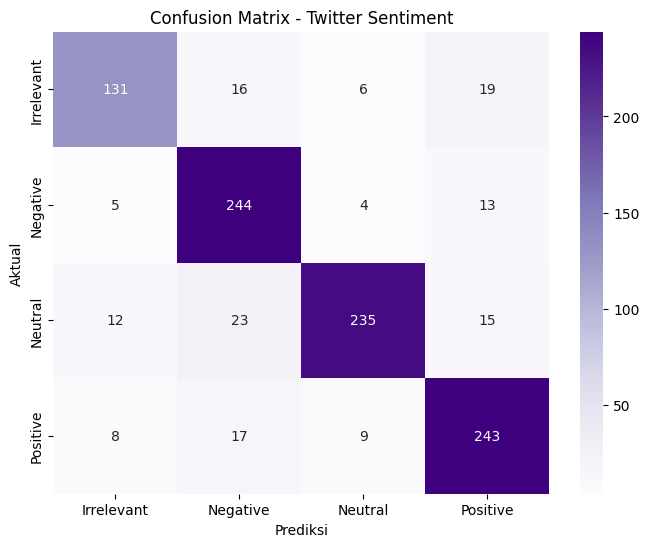

In [23]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_pred = model_nlp.predict(X_test_tfidf)

akurasi = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Akurasi Model : {akurasi*100:.2f}%")
print(f"F1-Score Macro : {f1:.4f}\n")

# 2. Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Twitter Sentiment")
plt.show()

In [24]:
import joblib
import os

os.makedirs('../model', exist_ok=True)

# Simpan model dan vectorizer
joblib.dump(model_nlp, '../model/model_sentimen_twitter.pkl')
joblib.dump(tfidf_vectorizer, '../model/vectorizer_tfidf_twitter.pkl')

print("Model dan Vectorizer Twitter sukses disimpan!")

Model dan Vectorizer Twitter sukses disimpan!


In [25]:
tweet_baru = "I really love this game"

# preprocessing
tweet_bersih = bersihkan_teks_twitter(tweet_baru)

# ekstraksi fitur
tweet_tfidf = tfidf_vectorizer.transform([tweet_bersih])

# prediksi
hasil = model_nlp.predict(tweet_tfidf)

print("Tweet :", tweet_baru)
print("Sentiment :", hasil[0])

Tweet : I really love this game
Sentiment : Positive
